[2026-07-18 14:48:36] [info     ] 按交易日逐日计算因子，区间：2019-01-01 00:00:00 ~ 2024-12-31 23:59:59
[latent_tick_flow_pressure_v1] 1/1456 2019-01-02
[latent_tick_flow_pressure_v1] 2/1456 2019-01-03
[latent_tick_flow_pressure_v1] 3/1456 2019-01-04


[latent_tick_flow_pressure_v1] 4/1456 2019-01-07
[latent_tick_flow_pressure_v1] 5/1456 2019-01-08
[latent_tick_flow_pressure_v1] 6/1456 2019-01-09
[latent_tick_flow_pressure_v1] 7/1456 2019-01-10
[latent_tick_flow_pressure_v1] 8/1456 2019-01-11
[latent_tick_flow_pressure_v1] 9/1456 2019-01-14
[latent_tick_flow_pressure_v1] 10/1456 2019-01-15
[latent_tick_flow_pressure_v1] 11/1456 2019-01-16
[latent_tick_flow_pressure_v1] 12/1456 2019-01-17
[latent_tick_flow_pressure_v1] 13/1456 2019-01-18
[latent_tick_flow_pressure_v1] 14/1456 2019-01-21
[latent_tick_flow_pressure_v1] 15/1456 2019-01-22
[latent_tick_flow_pressure_v1] 16/1456 2019-01-23
[latent_tick_flow_pressure_v1] 17/1456 2019-01-24
[latent_tick_flow_pressure_v1] 18/1456 2019-01-25
[latent_tick_flow_pressure_v1] 19/1456 2019-01-28
[latent_tick_flow_pressure_v1] 20/1456 2019-01-29
[latent_tick_flow_pressure_v1] 21/1456 2019-01-30
[latent_tick_flow_pressure_v1] 22/1456 2019-01-31
[latent_tick_flow_pressure_v1] 23/1456 2019-02-01
[laten

时段,IC
2020-02-03~2020-03-31,0.0111
2024-01-15~2024-02-08,-0.0005
2024-09-24~2024-10-08,0.0263

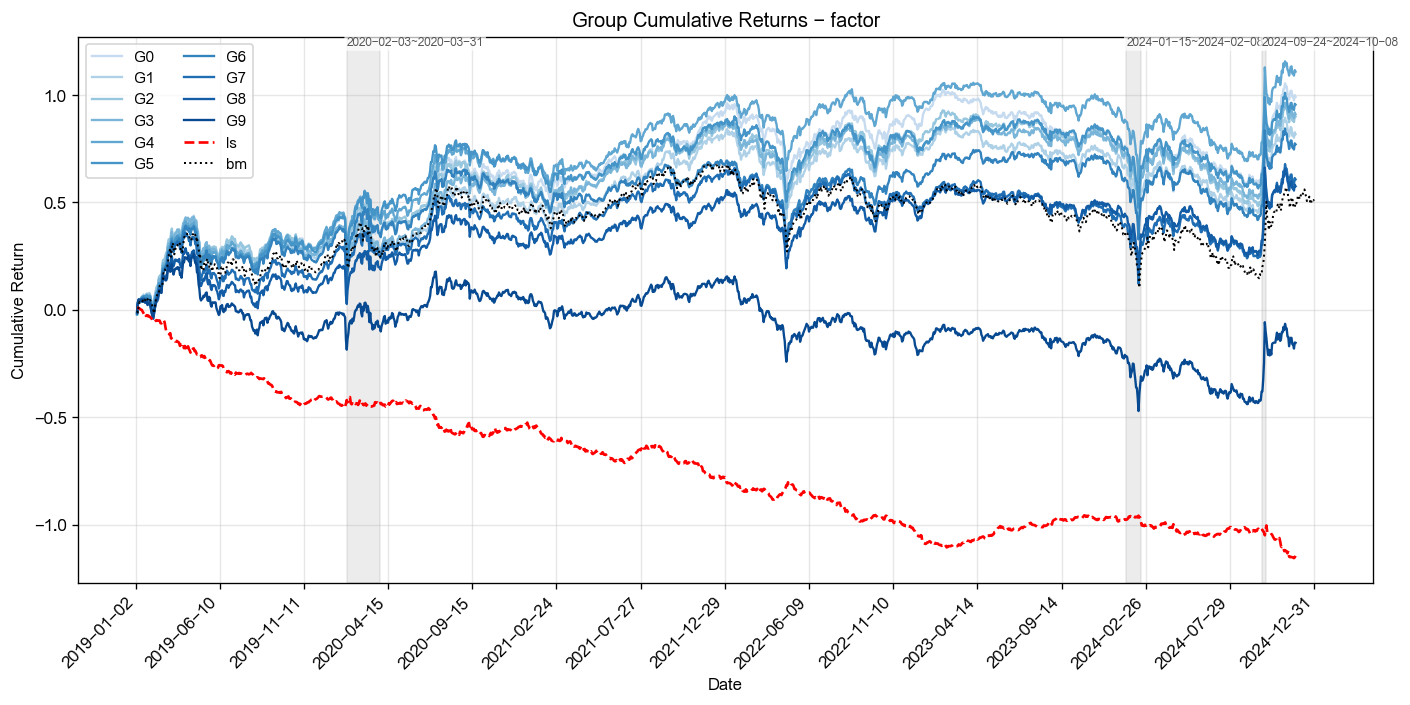
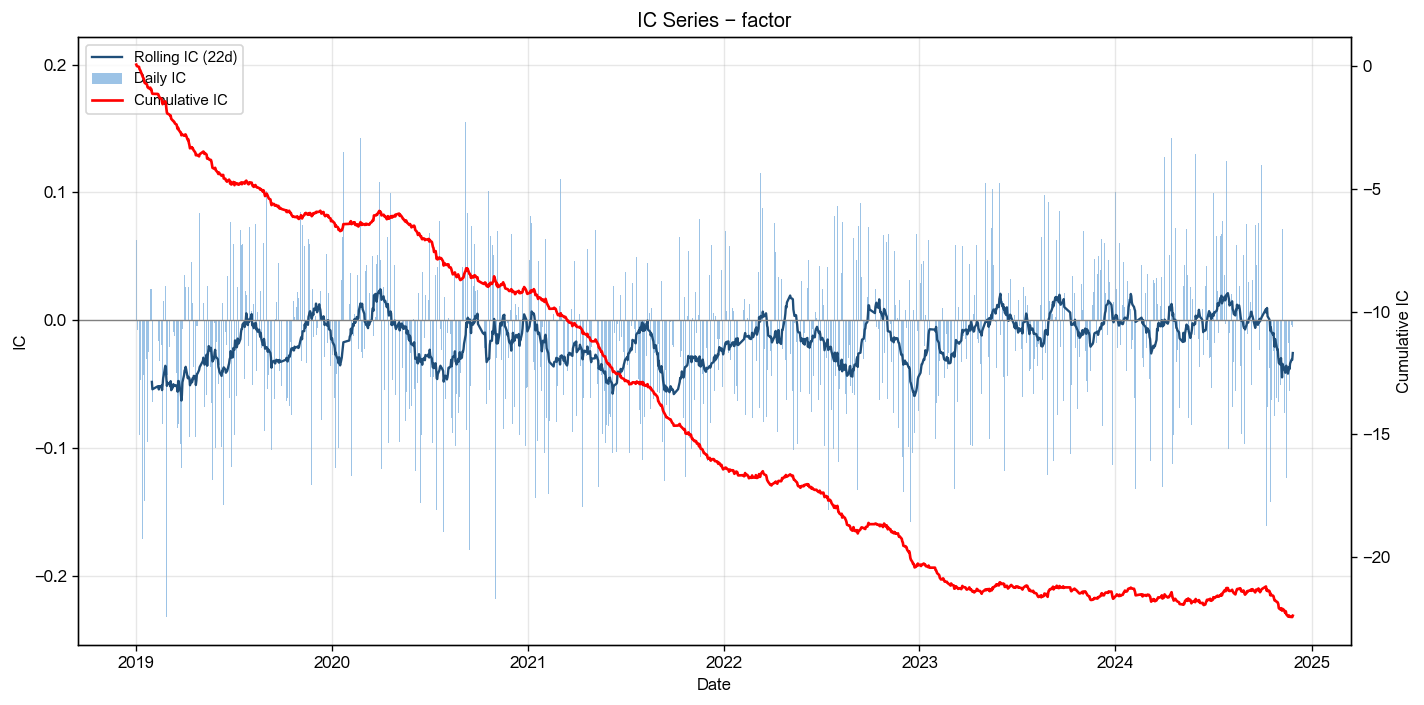
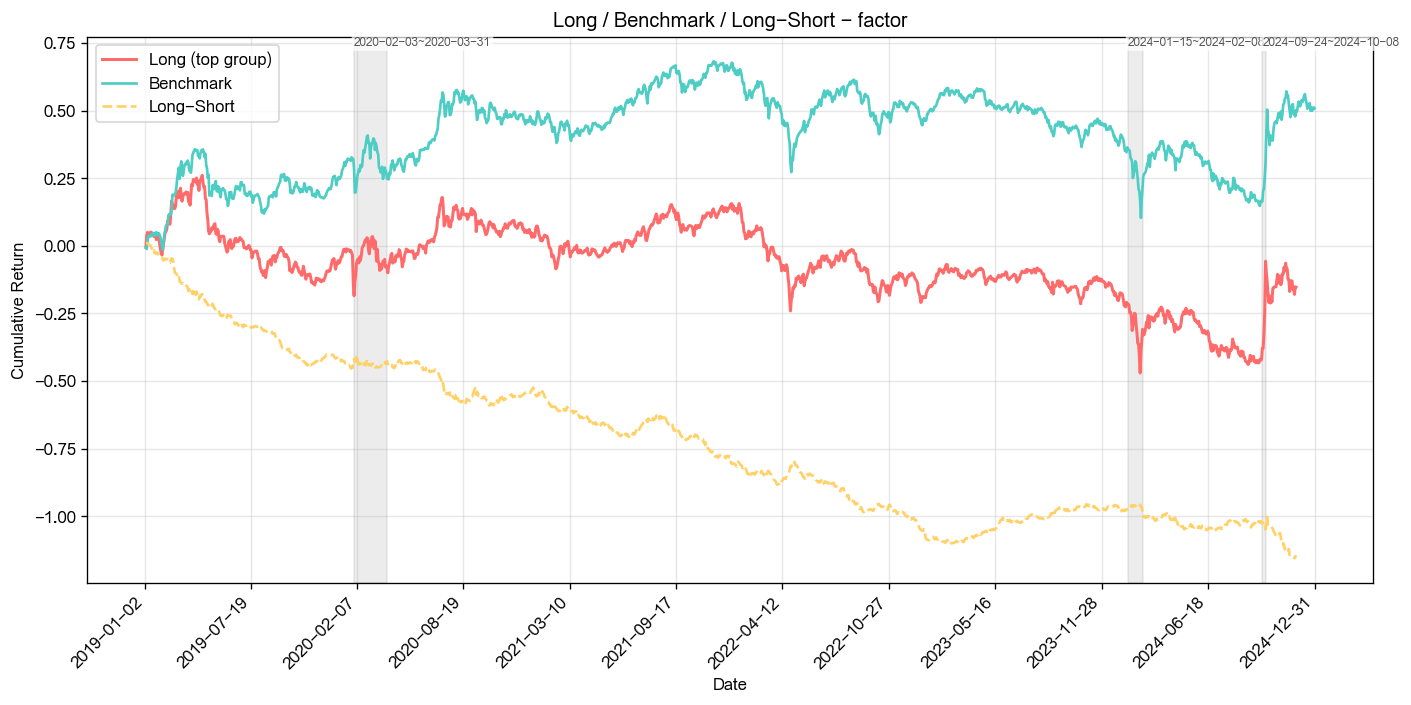
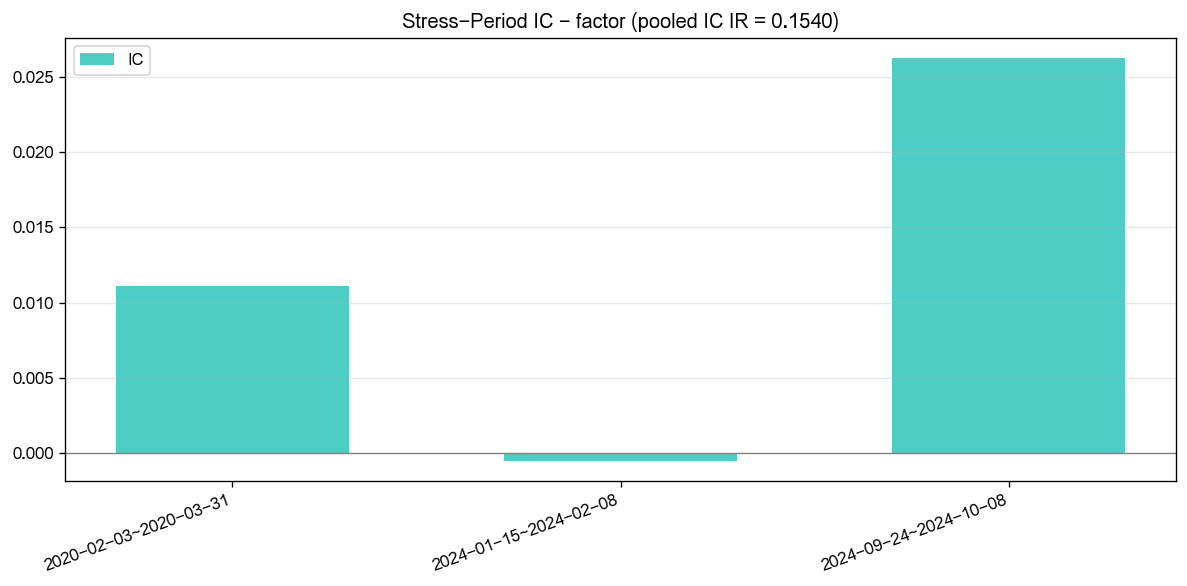
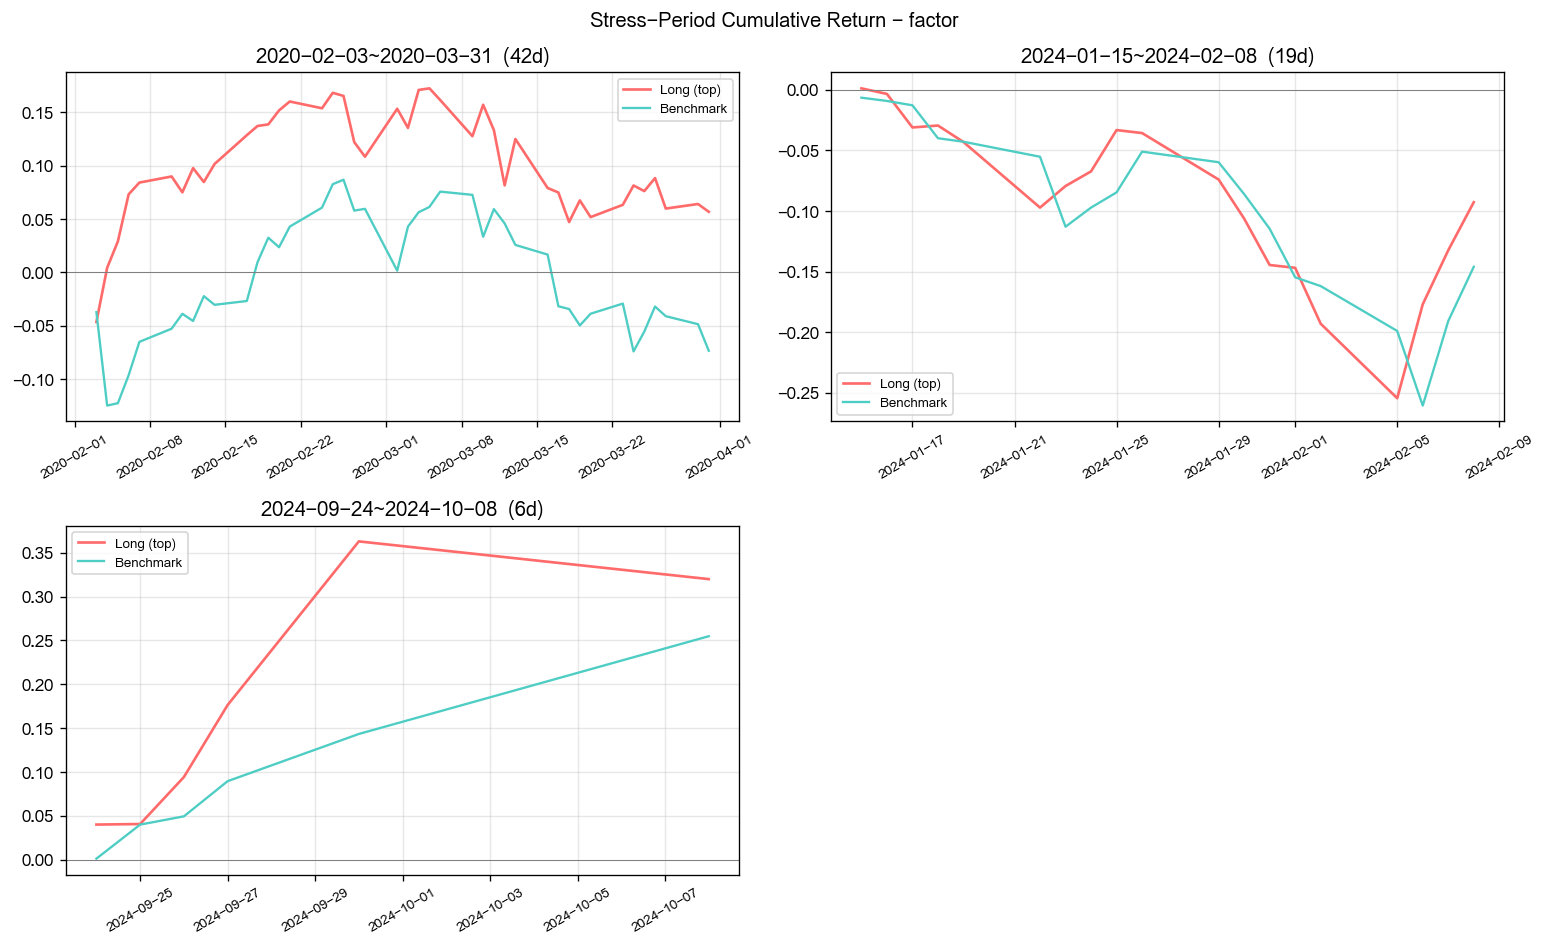

[2026-07-18 15:15:44] [info     ] ========== 因子池回归 ==========
[2026-07-18 15:15:46] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=2075 rows=2695583 start_date=2019-01-02
[2026-07-18 15:15:49] [info     ] 获取收益率数据, 耗时: 4.9918 秒
[2026-07-18 15:15:55] [info     ] 滚动 Elastic Net 拟合, 耗时: 6.4186 秒
[2026-07-18 15:15:55] [info     ] 统计 回归结果, 耗时: 0.0129 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.5398,0.0177,0.0115,0.9857
2,turn,1.4541,0.0265,0.0182,0.9429
3,bias_20,1.4079,0.0300,0.0213,0.9571
4,cci_14,1.3896,0.0293,0.0211,0.9857
5,momentum_5,1.3589,0.0179,0.0131,0.9571
6,list_days,1.3478,0.0104,0.0077,0.9571
7,net_active_buy_amount_main,1.2955,0.0164,0.0126,0.9286
8,reversal_5,1.2609,0.0090,0.0072,0.9571
9,ps_ttm,1.2584,0.0069,0.0055,0.9000
10,net_profit_rate_ttm,1.2572,0.0065,0.0052,0.9286

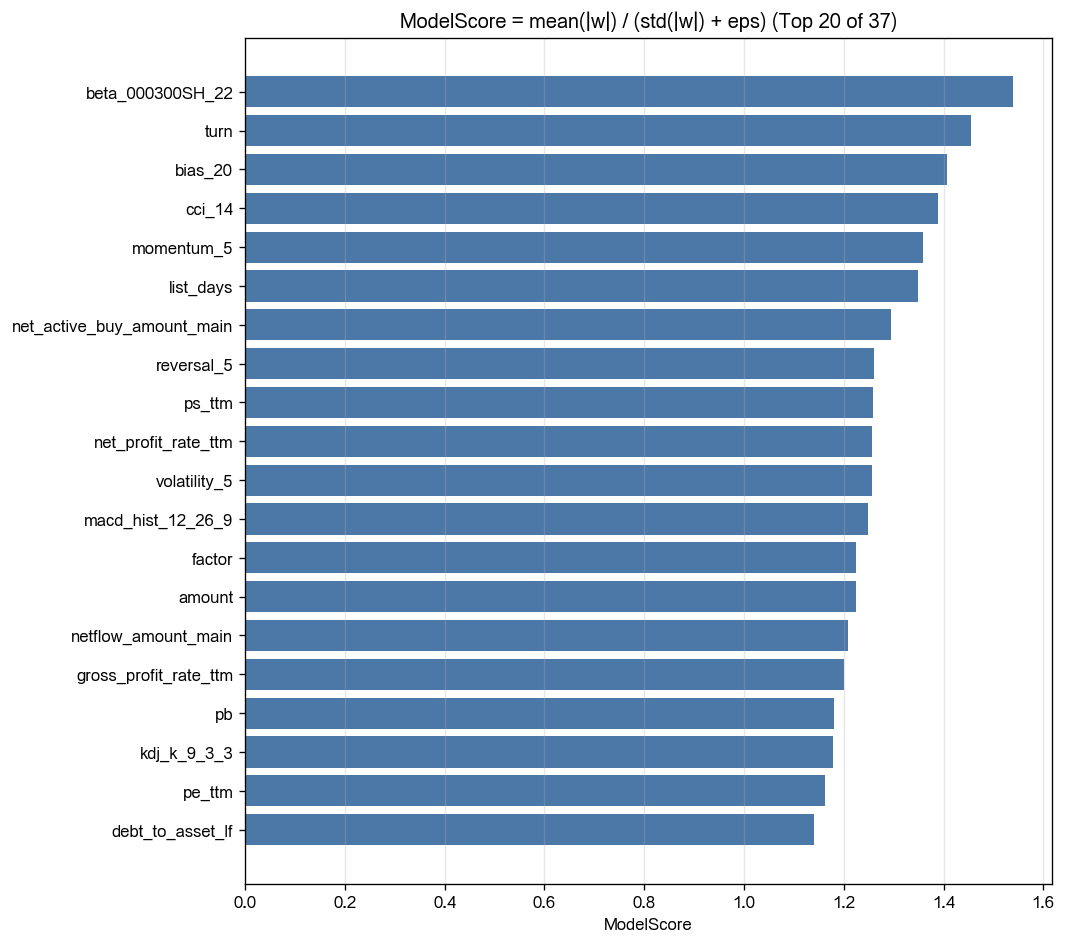
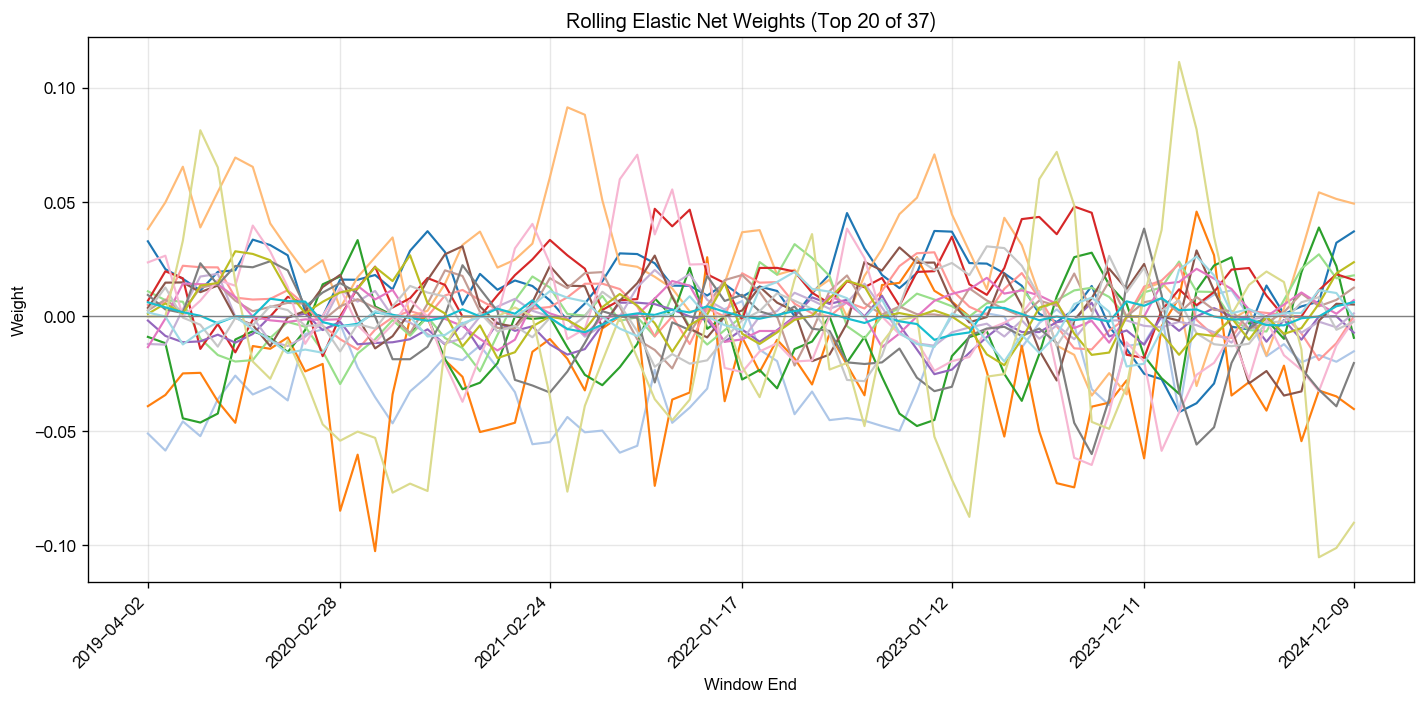
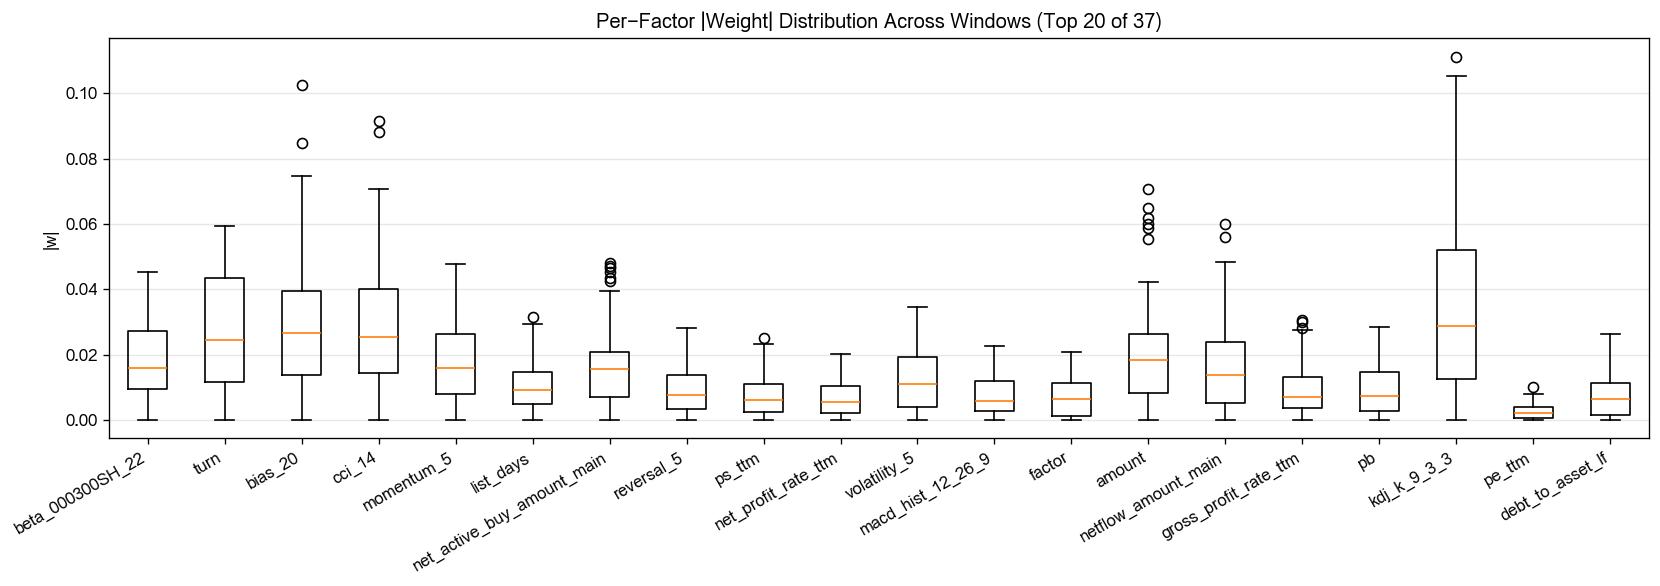
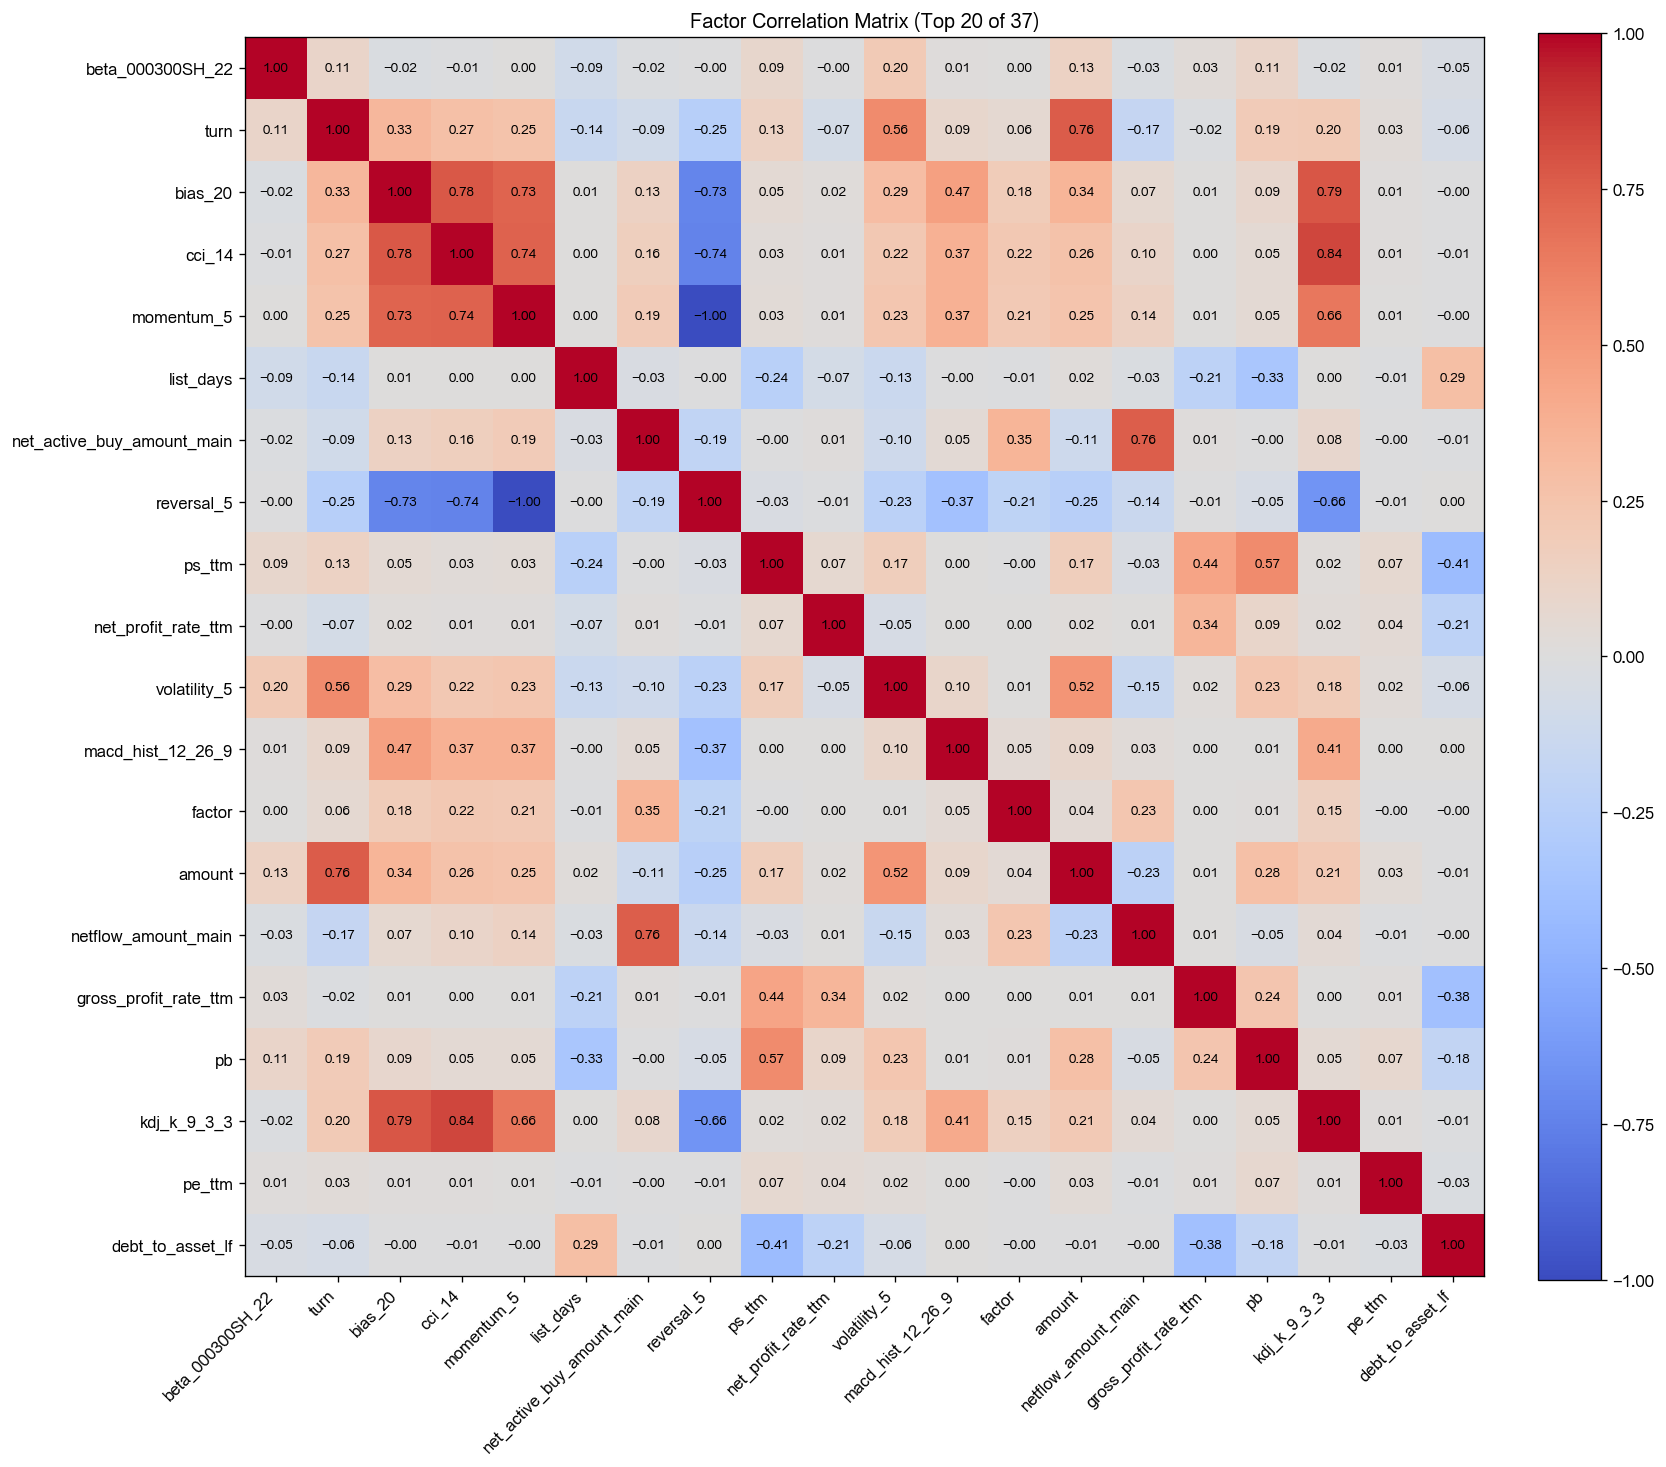

[2026-07-18 15:15:59] [warning  ] 返回的Outputs实例(size=218793594) 大于 64K, 将不会被缓存
[2026-07-18 15:15:59] [info     ] bigalpha_eval.v4 运行完成 [538.369s].


In [2]:
"""市场相对的渐进拥挤反转因子 v1。

把 T 日连续竞价切成 16 个独立的 15 分钟桶，衡量个股相对当日中证1000
同桶中位数收益的方向一致性，并惩罚由单个桶主导的离散冲击。持续跑赢被解释为
同方向追价库存和拥挤风险，持续跑输被解释为卖压释放后的修复机会，因此整体取负。
信号在 T 日收盘后形成，供 T+1 最早调仓；因子值越大预期越高。
"""


FACTOR_NAME = "gradual_relative_information_drift_v1"


def normalize_date(series):
    import pandas as pd

    return pd.to_datetime(series).dt.normalize().astype("datetime64[ns]")


def clean_factor(df):
    import numpy as np
    import pandas as pd

    out = df[["date", "instrument", "factor"]].copy()
    out["date"] = normalize_date(out["date"])
    out["instrument"] = out["instrument"].astype(str)
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    )
    return (
        out.drop_duplicates(["date", "instrument"], keep="last")
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )


def stabilize_constant_days(df):
    """仅处理罕见的全日常数截面，不把确定性扰动当作 alpha。"""
    import pandas as pd

    out = df.copy()
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce").fillna(0.0)
    daily_std = out.groupby("date")["factor"].transform("std").fillna(0.0)
    daily_unique = out.groupby("date")["factor"].transform("nunique").fillna(0)
    mask = (daily_std < 1e-12) | (daily_unique <= 1)
    if mask.any():
        code = out.loc[mask, "instrument"].astype(str).str.extract(r"(\d+)")[0]
        code = pd.to_numeric(code, errors="coerce").fillna(0.0)
        out.loc[mask, "factor"] = (
            ((code % 997.0) / 997.0 - 0.5).to_numpy() * 1e-4
        )
    return out


def query_daily_path_state(bar1m, start_date, end_date):
    """在 DAI 内依次压缩为15分钟桶、市场相对桶收益和日频路径状态。"""
    import dai
    import pandas as pd

    sql = f"""
    WITH cte_minute AS (
        SELECT
            b.date AS minute_time,
            strftime(b.date, '%Y-%m-%d') AS trading_day,
            b.instrument::STRING AS instrument,
            CASE
                WHEN CAST(strftime(b.date, '%H%M%S') AS INTEGER)
                     BETWEEN 93100 AND 113000
                THEN FLOOR((
                    CAST(strftime(b.date, '%H') AS INTEGER) * 60
                    + CAST(strftime(b.date, '%M') AS INTEGER) - 571
                ) / 15.0)
                WHEN CAST(strftime(b.date, '%H%M%S') AS INTEGER)
                     BETWEEN 130100 AND 150000
                THEN 8 + FLOOR((
                    CAST(strftime(b.date, '%H') AS INTEGER) * 60
                    + CAST(strftime(b.date, '%M') AS INTEGER) - 781
                ) / 15.0)
                ELSE NULL
            END AS bucket_id,
            b."close" AS close_price
        FROM {bar1m} AS b
        WHERE b."close" > 0
          AND (
              CAST(strftime(b.date, '%H%M%S') AS INTEGER)
                  BETWEEN 93100 AND 113000
              OR CAST(strftime(b.date, '%H%M%S') AS INTEGER)
                  BETWEEN 130100 AND 150000
          )
    ),
    cte_bucket AS (
        SELECT
            m.trading_day,
            m.instrument,
            m.bucket_id,
            FIRST(m.close_price ORDER BY m.minute_time) AS bucket_open,
            LAST(m.close_price ORDER BY m.minute_time) AS bucket_close,
            COUNT(*) AS minute_count
        FROM cte_minute AS m
        WHERE m.bucket_id BETWEEN 0 AND 15
        GROUP BY m.trading_day, m.instrument, m.bucket_id
    ),
    cte_lagged AS (
        SELECT
            b.trading_day,
            b.instrument,
            b.bucket_id,
            b.bucket_open,
            b.bucket_close,
            b.minute_count,
            LAG(b.bucket_close) OVER (
                PARTITION BY b.trading_day, b.instrument
                ORDER BY b.bucket_id
            ) AS previous_bucket_close
        FROM cte_bucket AS b
    ),
    cte_bucket_return AS (
        SELECT
            l.trading_day,
            l.instrument,
            l.bucket_id,
            LOG(
                l.bucket_close
                / NULLIF(COALESCE(l.previous_bucket_close, l.bucket_open), 0)
            ) AS bucket_return
        FROM cte_lagged AS l
        WHERE l.minute_count >= 5
          AND l.bucket_close > 0
          AND COALESCE(l.previous_bucket_close, l.bucket_open) > 0
    ),
    cte_pool_return AS (
        SELECT
            r.trading_day,
            r.instrument,
            r.bucket_id,
            r.bucket_return
        FROM cte_bucket_return AS r
        JOIN bigalpha_2026_instruments AS p
          ON CAST(r.trading_day AS DATETIME) = p.date
         AND r.instrument = p.instrument::STRING
        WHERE r.bucket_return IS NOT NULL
    ),
    cte_market AS (
        SELECT
            r.trading_day,
            r.bucket_id,
            MEDIAN(r.bucket_return) AS market_bucket_return
        FROM cte_pool_return AS r
        GROUP BY r.trading_day, r.bucket_id
    ),
    cte_excess AS (
        SELECT
            r.trading_day,
            r.instrument,
            r.bucket_id,
            r.bucket_return - m.market_bucket_return AS excess_return
        FROM cte_pool_return AS r
        JOIN cte_market AS m
          ON r.trading_day = m.trading_day
         AND r.bucket_id = m.bucket_id
    ),
    cte_daily AS (
        SELECT
            e.trading_day,
            e.instrument,
            COUNT(*) AS bucket_count,
            SUM(e.excess_return) AS net_excess_return,
            SUM(e.excess_return * e.excess_return) AS excess_energy,
            MAX(e.excess_return * e.excess_return) AS max_bucket_energy
        FROM cte_excess AS e
        GROUP BY e.trading_day, e.instrument
    )
    SELECT
        CAST(d.trading_day AS DATETIME) AS date,
        d.instrument,
        d.bucket_count,
        d.net_excess_return,
        d.excess_energy,
        CASE
            WHEN d.excess_energy > 1e-16
            THEN 1.0 - d.max_bucket_energy / d.excess_energy
            ELSE NULL
        END AS continuity,
        CASE
            WHEN d.bucket_count >= 12 AND d.excess_energy > 1e-16
            THEN -1.0 * d.net_excess_return / SQRT(d.excess_energy)
                 * (1.0 - d.max_bucket_energy / d.excess_energy)
            ELSE NULL
        END AS raw_signal
    FROM cte_daily AS d
    ORDER BY d.trading_day, d.instrument
    """
    out = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()
    if out.empty:
        return pd.DataFrame(
            columns=[
                "date",
                "instrument",
                "bucket_count",
                "net_excess_return",
                "excess_energy",
                "continuity",
                "raw_signal",
            ]
        )
    out["date"] = normalize_date(out["date"])
    out["instrument"] = out["instrument"].astype(str)
    for column in [
        "bucket_count",
        "net_excess_return",
        "excess_energy",
        "continuity",
        "raw_signal",
    ]:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype(float)
    return out.drop_duplicates(["date", "instrument"], keep="last")


def align_to_stock_pool(raw_factor, start_date, end_date):
    import dai
    import pandas as pd

    pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    pool["date"] = normalize_date(pool["date"])
    pool["instrument"] = pool["instrument"].astype(str)
    out = pool.merge(raw_factor, how="left", on=["date", "instrument"])
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce").fillna(0.0)
    return clean_factor(stabilize_constant_days(out))


def main(datasources, start_date, end_date):
    """官方入口：完整使用 T 日数据，T 收盘后形成，预测下一期收益。"""
    import pandas as pd

    state = query_daily_path_state(datasources["bar1m"], start_date, end_date)
    raw = state[["date", "instrument", "raw_signal"]].rename(
        columns={"raw_signal": "factor"}
    )
    raw["factor"] = pd.to_numeric(raw["factor"], errors="coerce")
    return align_to_stock_pool(raw, start_date, end_date)


def run_field_probe(datasources, probe_date="2024-06-14"):
    """首次运行字段探针：确认16桶覆盖和非退化的相对路径状态。"""
    import pandas as pd

    start = f"{probe_date} 00:00:00"
    end = f"{probe_date} 23:59:59"
    state = query_daily_path_state(datasources["bar1m"], start, end)
    print(f"=== {FACTOR_NAME} FIELD PROBE ===", flush=True)
    print(f"probe_date={probe_date} rows={len(state)}", flush=True)
    if not state.empty:
        valid = pd.to_numeric(state["raw_signal"], errors="coerce").notna()
        print(
            {
                "stocks": int(state["instrument"].nunique()),
                "valid_stocks": int(valid.sum()),
                "median_bucket_count": float(state["bucket_count"].median()),
                "factor_std": float(state.loc[valid, "raw_signal"].std()),
                "positive_rate": float((state.loc[valid, "raw_signal"] > 0).mean()),
            },
            flush=True,
        )
        print(
            state[["bucket_count", "continuity", "raw_signal"]]
            .describe()
            .round(6),
            flush=True,
        )
    return state


def run_factor_by_trading_day(datasources, start_date, end_date):
    """纯分钟因子严格逐日执行，并每20日合并一次以控制内存。"""
    import gc
    import dai
    import pandas as pd

    dates = pd.to_datetime(
        dai.query(
            "SELECT DISTINCT date FROM bigalpha_2026_instruments ORDER BY date",
            filters={"date": [start_date, end_date]},
        ).df()["date"]
    ).dt.normalize()
    chunks, current = [], []
    total = len(dates)
    for index, day in enumerate(dates, start=1):
        day_text = day.strftime("%Y-%m-%d")
        print(f"[{FACTOR_NAME}] {index}/{total} {day_text}", flush=True)
        current.append(
            main(
                datasources,
                f"{day_text} 00:00:00",
                f"{day_text} 23:59:59",
            )
        )
        if len(current) >= 20:
            chunks.append(pd.concat(current, ignore_index=True))
            current = []
            gc.collect()
    if current:
        chunks.append(pd.concat(current, ignore_index=True))
    if not chunks:
        return pd.DataFrame(columns=["date", "instrument", "factor"])
    return clean_factor(pd.concat(chunks, ignore_index=True))


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2019-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    run_field_probe(datasources, "2024-06-14")
    logger.info(f"严格逐交易日计算因子：{start_date} ~ {end_date}")
    factor_data = run_factor_by_trading_day(datasources, start_date, end_date)
    logger.info("读取平台因子库并运行正式单因子评测")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
        start_date=start_date,
        end_date=end_date,
    )
